In [1]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

In [2]:
# Download latest version
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset", output_dir= "/home/adriel/Downloads/spotify_dataset")

print("Dataset baixado em:", path)

Dataset baixado em: Path to.../spotify_dataset


In [ ]:
df = pd.read_csv('Path to.../spotify_dataset/dataset.csv', sep=',', header = 0)

In [4]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.columns


Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [5]:
df = df.drop(['Unnamed: 0', 'track_id', 'album_name'], axis=1)

In [6]:
df.head(5)

,artists,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,Ben Woodward,Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,Kina Grannis,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,Chord Overstreet,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [7]:
resumo = df.groupby('track_genre')['popularity'].agg(['mean', 'max', 'count']).sort_values(by='mean', ascending= False)
print('Resumo de popularidade por gênero musical')
print(resumo)

Resumo de popularidade por gênero musical
                     mean  max  count
track_genre                          
pop-film        59.283000   80   1000
k-pop           56.952953   88    999
chill           53.651000   93   1000
sad             52.379000   83   1000
grunge          49.594000   85   1000
...                   ...  ...    ...
chicago-house   12.339000   78   1000
detroit-techno  11.174000   58   1000
latin            8.297000   98   1000
romance          3.245000   35   1000
iranian          2.210000   33   1000

[114 rows x 3 columns]


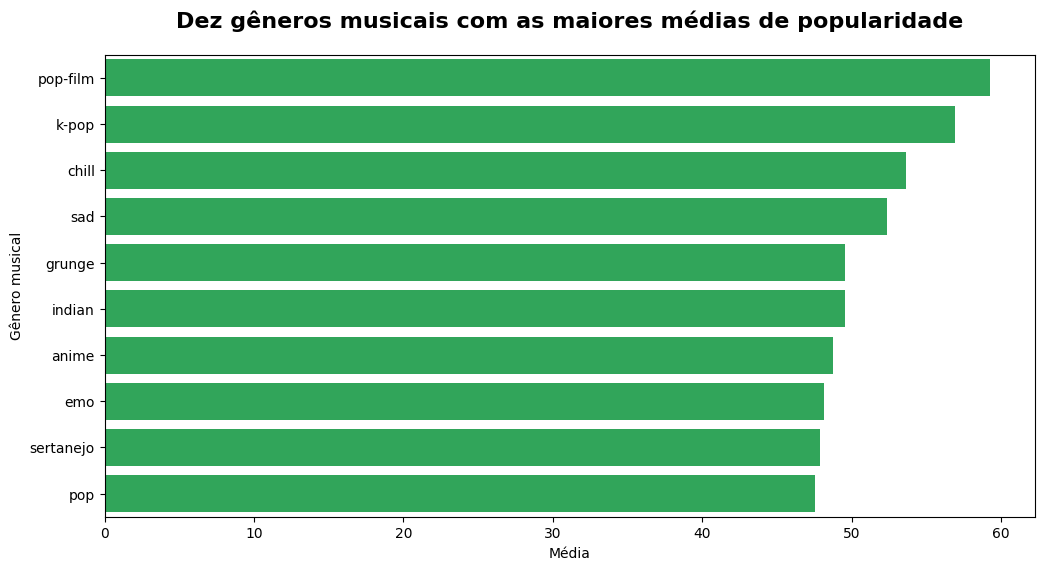

In [8]:
resumo = resumo.head(10)

plt.figure(figsize=(12,6))
sns.barplot(data = resumo, x = 'mean', y = 'track_genre', color = "#1DB954")
plt.ylabel('Gênero musical')
plt.xlabel('Média')
plt.title('Dez gêneros musicais com as maiores médias de popularidade',fontsize = 16, fontweight = 'bold', pad = 20)
plt.show()

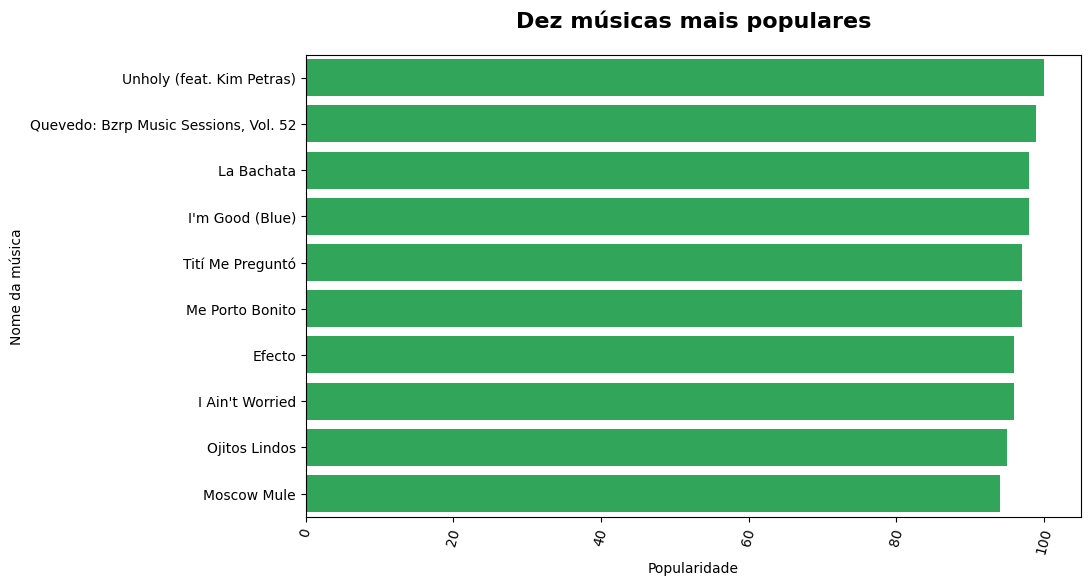

In [9]:
df_pop_songs10 = df.drop_duplicates(subset=['track_name']).sort_values(by='popularity', ascending=False).head(10)


plt.figure(figsize=(10,6))
sns.barplot(data = df_pop_songs10, y = 'track_name', x ='popularity', color = "#1DB954")
plt.xticks(rotation = 75)
plt.ylabel('Nome da música')
plt.xlabel('Popularidade')
plt.title('Dez músicas mais populares',fontsize = 16, fontweight = 'bold', pad = 20)
plt.show()

<Figure size 1200x600 with 0 Axes>

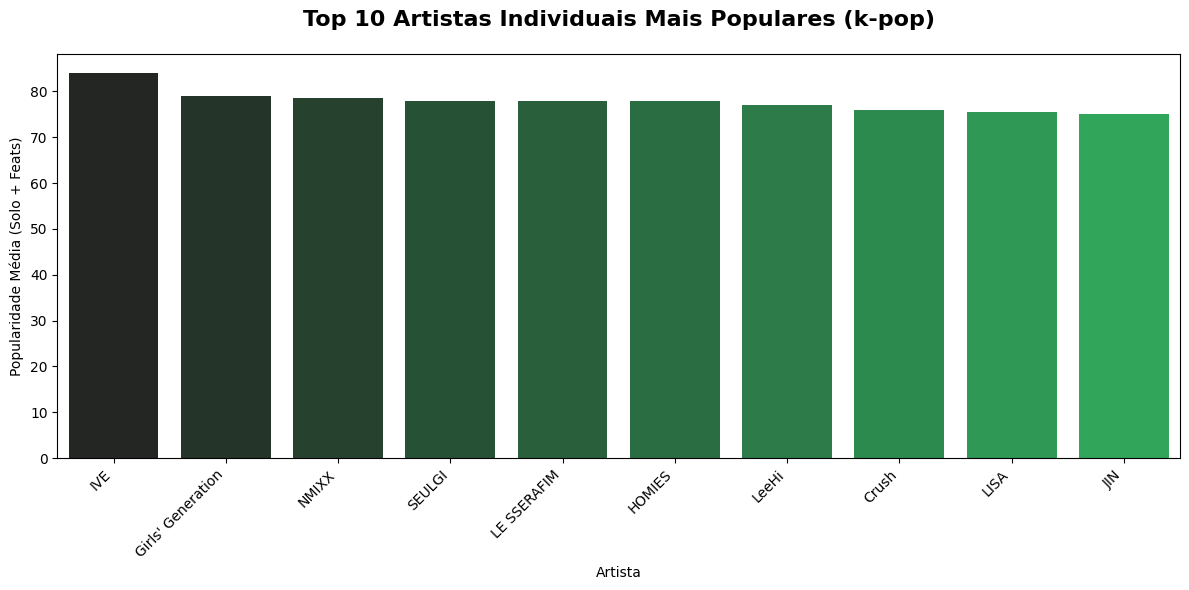

In [10]:
genre = 'k-pop'

df_genre = df[df['track_genre'] == genre].copy()

df_genre['artist_list'] = df_genre['artists'].str.split(';') # Transforma a string numa lista

df_exploded = df_genre.explode('artist_list') # O 'explode' cria uma linha individual para CADA artista mantendo a mesma popularidade

df_exploded['artist_list'] = df_exploded['artist_list'].str.strip()  # Remover espaços extras que possam existir nos nomes

df_pop_artists = df_exploded.groupby('artist_list')['popularity'].mean().reset_index().sort_values(by='popularity', ascending=False).head(10)





spotify_seq_10 = sns.dark_palette("#1DB954", n_colors=10)  # Cria a paleta sequencial de 10 tons, do mais claro até o verde oficial

plt.figure(figsize=(12, 6))


plt.figure(figsize=(12, 6))
sns.barplot(data=df_pop_artists, x='artist_list', y='popularity', hue='artist_list',palette=spotify_seq_10)

plt.xticks(rotation=45, ha='right')
plt.title(f'Top 10 Artistas Individuais Mais Populares ({genre})',fontsize = 16, fontweight = 'bold', pad = 20)
plt.xlabel('Artista')
plt.ylabel('Popularidade Média (Solo + Feats)')

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

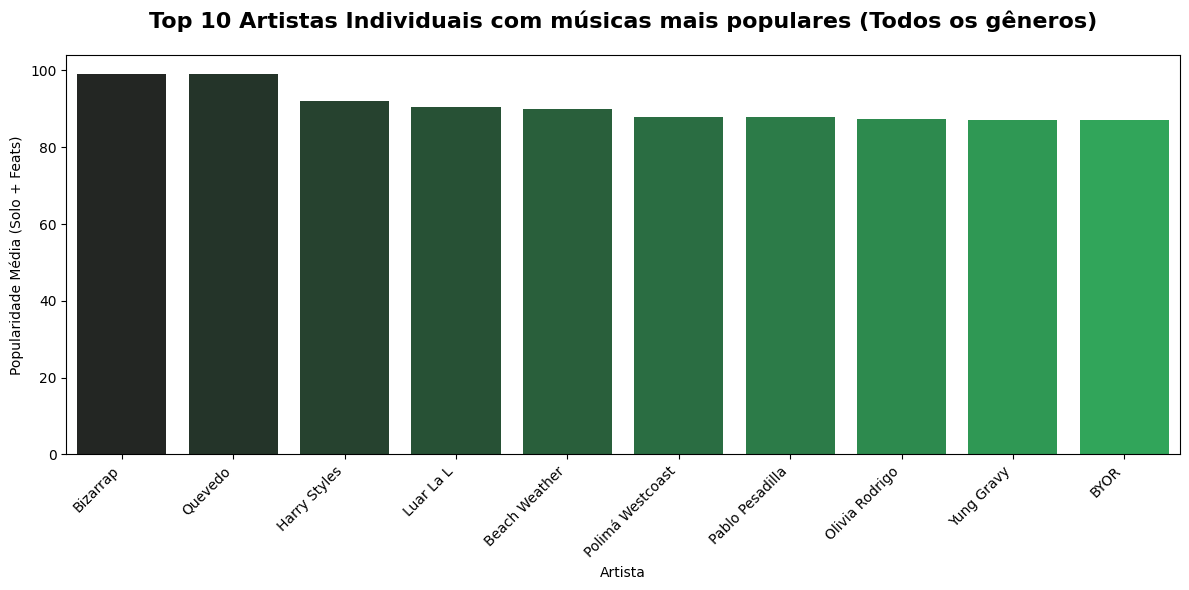

In [11]:
df_pop_artists = df.copy()

df_pop_artists['artists_list'] = df_pop_artists['artists'].str.split(';')  #Transforma novamente uma string com vários artistas em uma lista com os artistas individualmente
df_artists_exploded = df_pop_artists.explode('artists_list') # O 'explode' cria uma linha individual para CADA artista mantendo a mesma popularidade

df_pop_artists = df_artists_exploded.groupby('artists_list')['popularity'].mean().reset_index().sort_values(by = 'popularity' , ascending = False).head(10)

#df_artists_exploded[df_artists_exploded['track_name'] == 'Unholy (feat. Kim Petras)']


spotify_seq_10 = sns.dark_palette("#1DB954", n_colors=10)

plt.figure(figsize=(12, 6))


plt.figure(figsize=(12, 6))
sns.barplot(data = df_pop_artists, x = 'artists_list', y='popularity', hue='artists_list', palette=spotify_seq_10)

plt.xticks(rotation=45, ha='right')
plt.title(f'Top 10 Artistas Individuais com músicas mais populares (Todos os gêneros)',fontsize = 16, fontweight = 'bold', pad = 20)
plt.xlabel('Artista')
plt.ylabel('Popularidade Média (Solo + Feats)')

plt.tight_layout()
plt.show()


In [12]:
df

,artists,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,Ben Woodward,Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,Kina Grannis,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,Chord Overstreet,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,Rainy Lullaby,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,Rainy Lullaby,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,Cesária Evora,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,Michael W. Smith,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


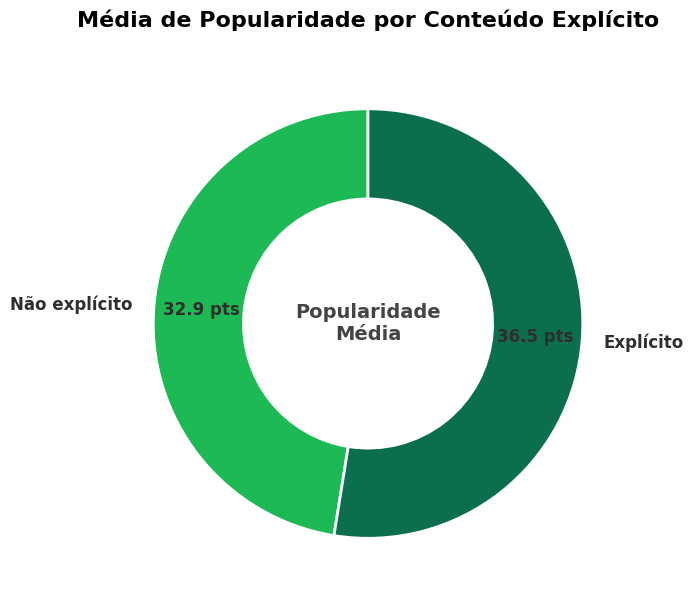

In [13]:
df_explicit = df.copy()

df_explicit['code_explicit'] = np.where(df_explicit['explicit'], 1, 0) # Cria um código de 1 para músicas com caonteúdo explícito e 0 para conteúdo não explícito

mean_pop_explicit = df_explicit.groupby('code_explicit')['popularity'].mean()



plt.figure(figsize=(7, 7))

cores = ['#1DB954', '#0B6E4F'] 

plt.pie(mean_pop_explicit,
    labels = ['Não explícito', 'Explícito'],
    colors = cores,
    startangle = 90,
    autopct = lambda p: f'{p * mean_pop_explicit.sum() / 100:.1f} pts',
    pctdistance = 0.78,
    textprops={'fontsize': 12, 'fontweight': 'bold', 'color': '#2E2E2E'},
    wedgeprops={'width': 0.42, 'edgecolor': 'white', 'linewidth': 2})


plt.text(0, 0,'Popularidade\nMédia', ha='center', va='center', fontsize=14, fontweight='bold', color='#444444')

plt.title('Média de Popularidade por Conteúdo Explícito',fontsize = 16, fontweight = 'bold', pad = 20)

plt.tight_layout()
plt.show()

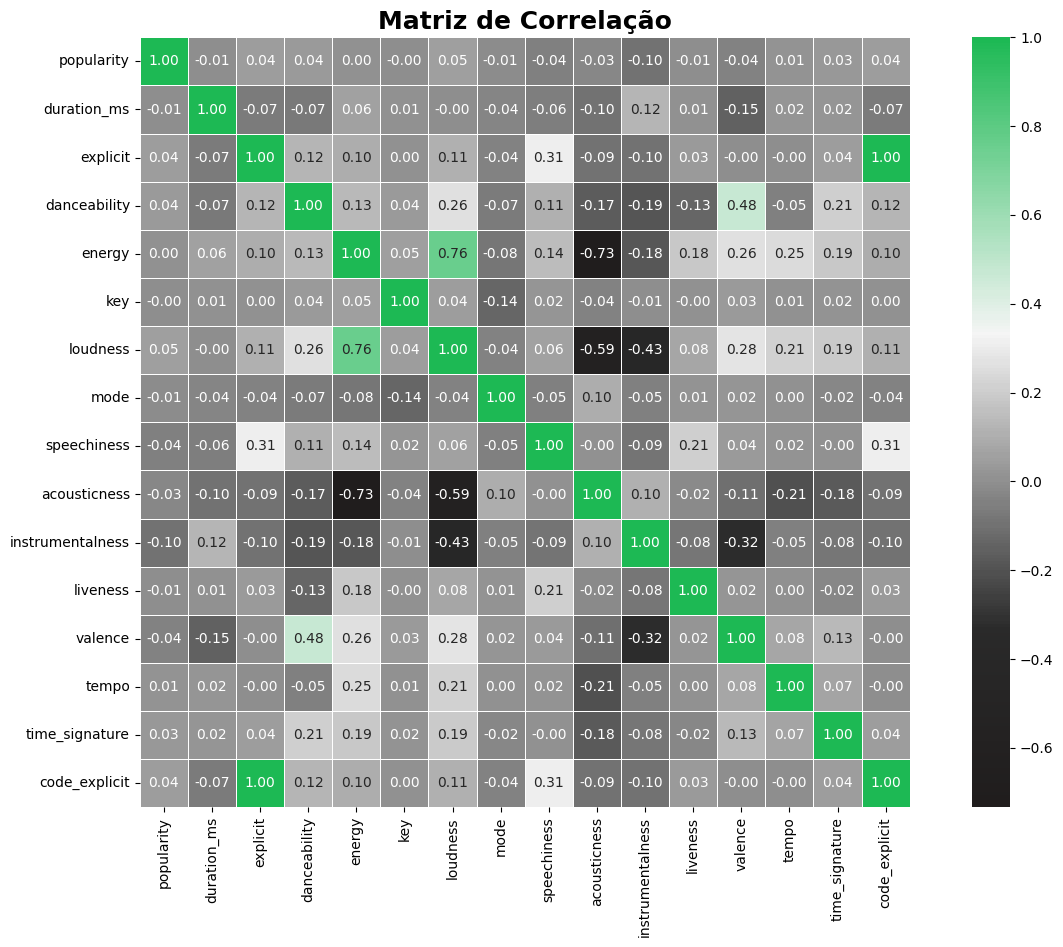

In [14]:
df_correlato = df_explicit.corr(numeric_only= True)


spotify_cmap = LinearSegmentedColormap.from_list("spotify",["#191414", "#2A2A2A", "#F5F5F5", "#1DB954"])

plt.figure(figsize=(16,10))

sns.heatmap(df_correlato, annot = True, cmap = spotify_cmap, center = 0, fmt = ".2f", linewidths = 0.5, square = True)

plt.title("Matriz de Correlação", fontsize=18, fontweight="bold")
plt.show()


In [37]:
#Vamos fazer uma pequena previsão de qual música é popular ou não dado uma nota de corte (60) para a popularidade e com modificações no DataFrame original para o caso de conteúdo explícito
df['target'] = (df['popularity'] > 70).astype(int)
df['code_explicit']= np.where(df_explicit['explicit'], 1, 0)
df

,artists,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,target,code_explicit
0,Gen Hoshino,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic,1,0
1,Ben Woodward,Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic,0,0
2,Ingrid Michaelson;ZAYN,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic,0,0
3,Kina Grannis,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic,1,0
4,Chord Overstreet,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,Rainy Lullaby,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music,0,0
113996,Rainy Lullaby,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music,0,0
113997,Cesária Evora,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music,0,0
113998,Michael W. Smith,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music,0,0


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report



x = df[['duration_ms','danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'code_explicit']]
y = df['target']


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.15, random_state = 42,  stratify = y)



model = RandomForestClassifier(class_weight = 'balanced' ,random_state = 42, n_estimators = 200)

model.fit(x_train, y_train)

predicoes = model.predict(x_test)

print(classification_report(y_test, predicoes))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99     16373
           1       0.75      0.65      0.70       727

    accuracy                           0.98     17100
   macro avg       0.86      0.82      0.84     17100
weighted avg       0.97      0.98      0.97     17100



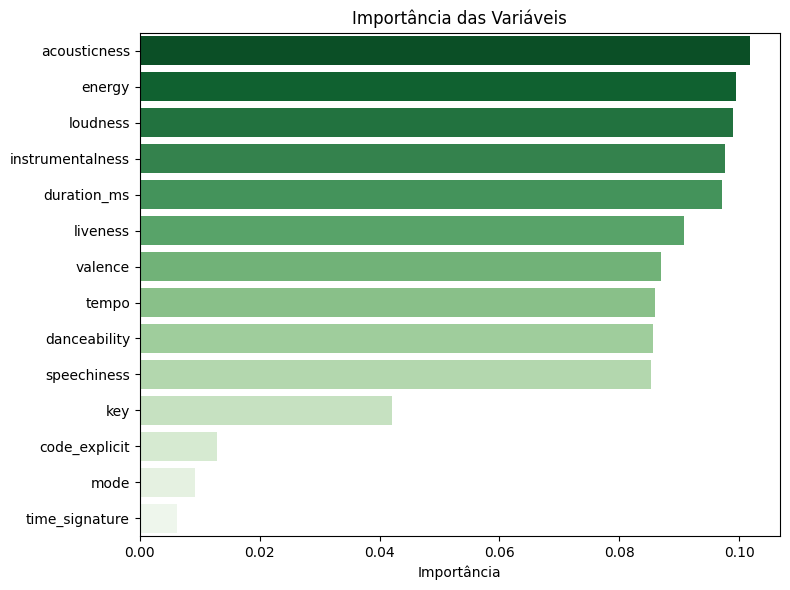

In [39]:
importancias = pd.DataFrame({"Feature": x_train.columns, "Importância": model.feature_importances_}).sort_values("Importância", ascending=False)

plt.figure(figsize=(8,6))

sns.barplot(
    data=importancias,
    x="Importância",
    y="Feature",
    hue="Feature",
    palette="Greens_r",
    legend=False)

plt.title("Importância das Variáveis")
plt.xlabel("Importância")
plt.ylabel("")

plt.tight_layout()
plt.show()


In [44]:
x_random_df = pd.DataFrame([[210000, 0.780, 0.850, 5, -4.50, 1, 0.045, 0.120, 0.000, 0.150, 0.750, 124.0, 4, 1]], 
                           columns=['duration_ms', 'danceability', 'energy', 'key', 'loudness', 
    'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'code_explicit'])

resultado = model.predict(x_random_df)

if resultado == 1:
    print('Essa música provavelmente será popular')

else:
    print('Essa música provavelmente não será popular') 

#print(f"A música aleatória foi classificada como: {resultado[0]}")


Essa música provavelmente não será popular
